# Bài Thực Hành Chương 1: Tổng Quan Thị Giác Máy Tính & Xử Lý Ảnh

**Môn học:** Xử Lý Ảnh & Thị Giác Máy Tính
**Chương:** 1 — Tổng quan về Thị giác máy tính và Xử lý ảnh

Notebook này thực hiện đầy đủ 5 mục của đề bài "Bài thực hành chương 1":

1. Cài đặt các thư viện OpenCV và Pillow
2. Đọc và hiển thị ảnh (đọc, hiển thị, lưu lại với định dạng khác)
3. Chuyển đổi không gian màu (RGB → Grayscale, HSV, LAB)
4. Cắt xén và thay đổi kích thước ảnh
5. Vẽ hình cơ bản (đường thẳng, hình tròn, hình chữ nhật) và thêm văn bản



---
## 1. Cài đặt các thư viện OpenCV và Pillow

Hai thư viện chính được dùng xuyên suốt notebook:
- **OpenCV (`cv2`)**: thư viện xử lý ảnh/thị giác máy tính mã nguồn mở, hiệu năng cao.
- **Pillow (`PIL`)**: thư viện xử lý ảnh thuần Python, giao diện trực quan, dễ dùng.



In [1]:
# !pip install opencv-python pillow numpy matplotlib

import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

print("OpenCV version :", cv2.__version__)
print("NumPy version  :", np.__version__)
import PIL
print("Pillow version :", PIL.__version__)


OpenCV version : 4.13.0
NumPy version  : 2.4.6
Pillow version : 12.2.0


---
## 2. Đọc và hiển thị ảnh

### 2.1. Đọc một hình ảnh bất kỳ từ máy tính

 OpenCV đọc ảnh theo thứ tự kênh màu **BGR** (Blue-Green-Red) thay vì RGB thông thường. Do đó, trước khi hiển thị bằng `matplotlib` (vốn mong đợi RGB), ta cần chuyển đổi bằng `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`.


In [2]:

IMAGE_PATH = "../Lab1/data/input/anhbien.jpg"

img_bgr = cv2.imread(IMAGE_PATH)

if img_bgr is None:
    raise FileNotFoundError(
        f"Không tìm thấy ảnh tại '{IMAGE_PATH}'. "
        "Hãy đặt một ảnh vào thư mục data/input/ và cập nhật lại IMAGE_PATH."
    )

print("Kích thước ảnh (cao, rộng, kênh màu):", img_bgr.shape)
print("Kiểu dữ liệu pixel:", img_bgr.dtype)


Kích thước ảnh (cao, rộng, kênh màu): (900, 1200, 3)
Kiểu dữ liệu pixel: uint8


### 2.2. Hiển thị hình ảnh đó lên màn hình

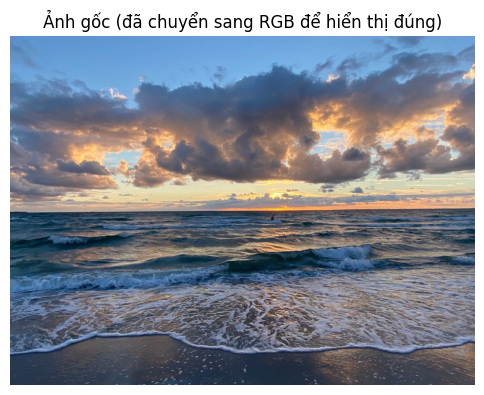

In [3]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("Ảnh gốc (đã chuyển sang RGB để hiển thị đúng)")
plt.axis("off")
plt.show()


### 2.3. Lưu hình ảnh đã xử lý lại với định dạng khác

Ví dụ: đọc ảnh `.jpg` và lưu lại dưới định dạng `.png`. OpenCV tự nhận diện định dạng output dựa trên đuôi file truyền vào `cv2.imwrite()`.


In [4]:
import os

OUTPUT_DIR = "../data/input/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

output_path = os.path.join(OUTPUT_DIR, "anh_da_luu.png")

success = cv2.imwrite(output_path, img_bgr)
print("Lưu ảnh thành công!" if success else "Lưu ảnh thất bại!")
print("Đường dẫn:", output_path)

pil_img = Image.open(IMAGE_PATH)
pil_output_path = os.path.join(OUTPUT_DIR, "anh_da_luu_pillow.png")
pil_img.save(pil_output_path)
print("Pillow cũng đã lưu ảnh tại:", pil_output_path)


Lưu ảnh thành công!
Đường dẫn: ../data/input/outputs\anh_da_luu.png
Pillow cũng đã lưu ảnh tại: ../data/input/outputs\anh_da_luu_pillow.png


---
## 3. Chuyển đổi không gian màu

Nhắc lại lý thuyết (Chương 1):
- **RGB**: mô hình màu cộng (Additive), dựa trên 3 kênh Đỏ - Lục - Lam.
- **Grayscale**: ảnh xám, mỗi pixel chỉ còn 1 giá trị cường độ sáng trong [0, 255]. Công thức chuẩn: `Y = 0.2989*R + 0.5870*G + 0.1140*B`.
- **HSV**: biểu diễn màu theo Hue (sắc độ), Saturation (độ bão hòa), Value (độ sáng) — trực quan hơn cho con người, hay dùng trong phân đoạn theo màu.
- **LAB**: không gian màu trong đó L là độ sáng, A/B là 2 trục màu — gần với cách mắt người cảm nhận sự khác biệt màu sắc.

### 3.1. Chuyển đổi ảnh từ RGB sang grayscale


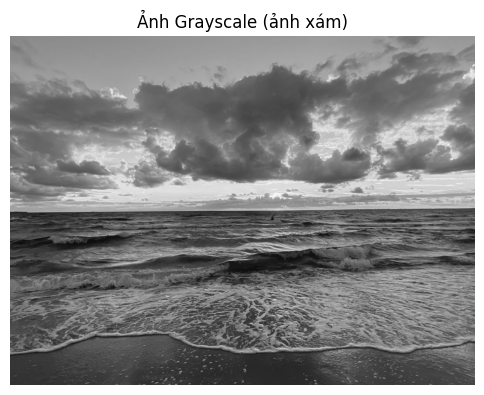

Kích thước ảnh xám (chỉ còn 2 chiều, không có kênh màu): (900, 1200)


In [5]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 6))
plt.imshow(gray, cmap="gray")
plt.title("Ảnh Grayscale (ảnh xám)")
plt.axis("off")
plt.show()

print("Kích thước ảnh xám (chỉ còn 2 chiều, không có kênh màu):", gray.shape)


### 3.2. Chuyển đổi ảnh sang các không gian màu khác như HSV, LAB

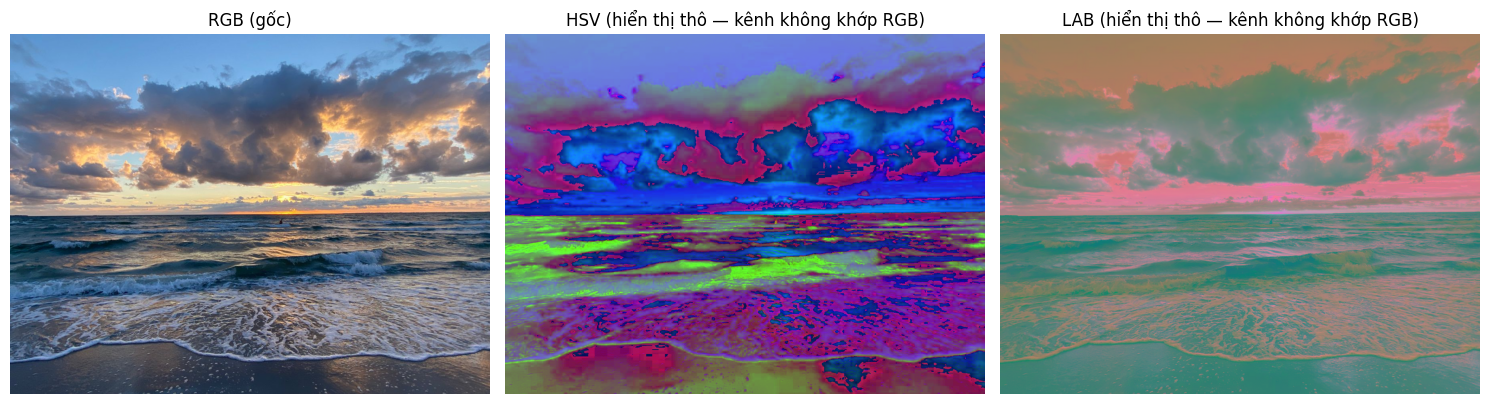

In [6]:
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("RGB (gốc)")

axes[1].imshow(hsv)
axes[1].set_title("HSV (hiển thị thô — kênh không khớp RGB)")

axes[2].imshow(lab)
axes[2].set_title("LAB (hiển thị thô — kênh không khớp RGB)")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

 Khi `matplotlib.imshow()` hiển thị ảnh HSV/LAB, nó vẫn vẽ 3 kênh dữ liệu đó *như thể* chúng là R, G, B — nên màu sắc nhìn "kỳ lạ", không phản ánh đúng ý nghĩa Hue/Saturation/Value hay L/A/B. Đây là điều bình thường; muốn xem đúng ý nghĩa từng kênh, ta nên tách kênh ra xem riêng:


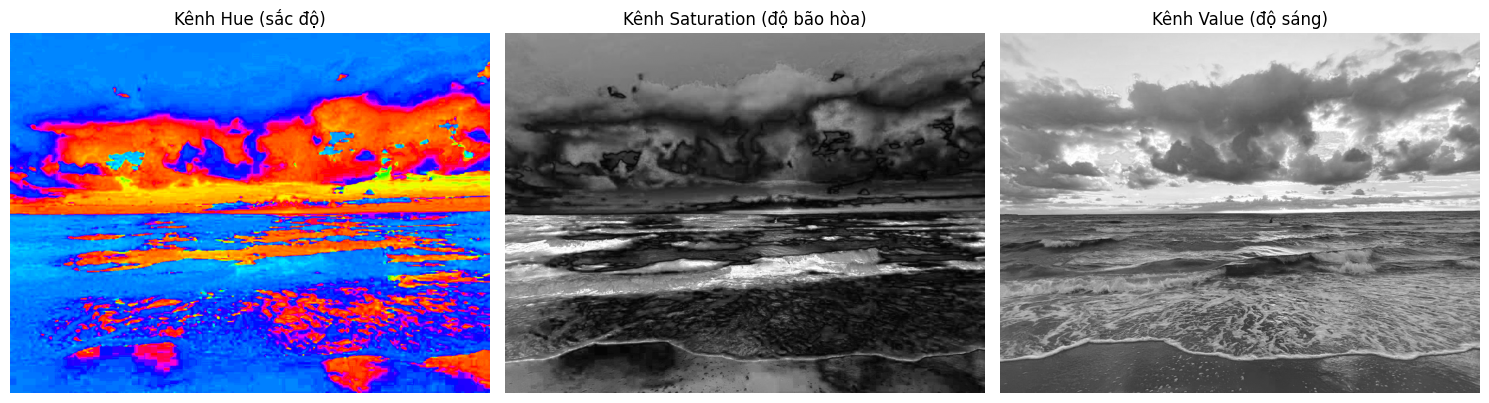

In [7]:
h, s, v = cv2.split(hsv)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(h, cmap="hsv")
axes[0].set_title("Kênh Hue (sắc độ)")
axes[1].imshow(s, cmap="gray")
axes[1].set_title("Kênh Saturation (độ bão hòa)")
axes[2].imshow(v, cmap="gray")
axes[2].set_title("Kênh Value (độ sáng)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


Tương tự, ta tách không gian màu **LAB** thành 3 kênh riêng: **L** (Lightness — độ sáng), **A** (trục màu Xanh lá ↔ Đỏ-tím), **B** (trục màu Xanh dương ↔ Vàng):


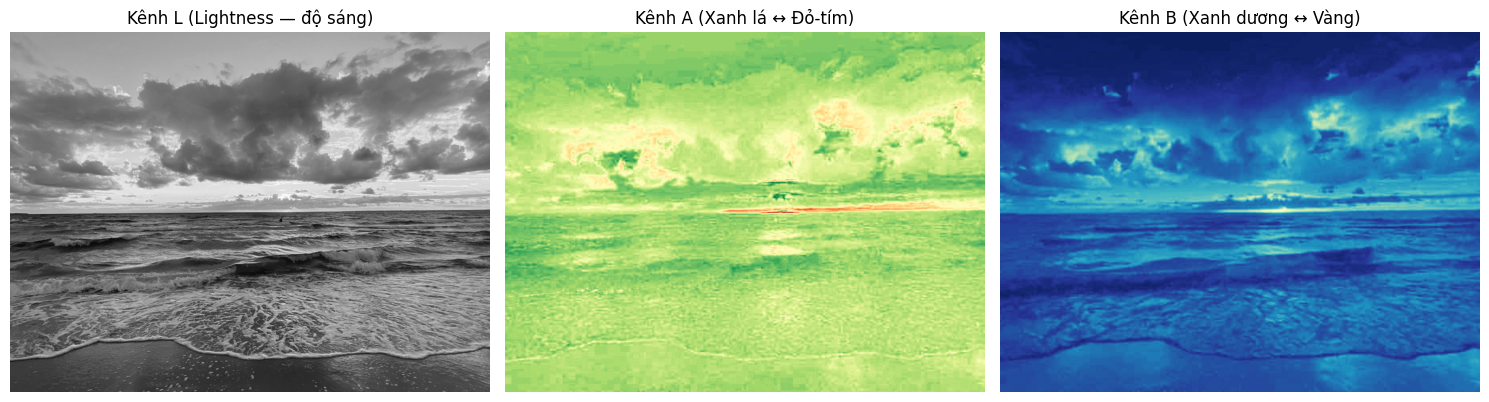

In [8]:
# Tách và hiển thị riêng từng kênh của không gian màu LAB
l, a, b = cv2.split(lab)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(l, cmap="gray")
axes[0].set_title("Kênh L (Lightness — độ sáng)")
axes[1].imshow(a, cmap="RdYlGn_r")
axes[1].set_title("Kênh A (Xanh lá ↔ Đỏ-tím)")
axes[2].imshow(b, cmap="YlGnBu_r")
axes[2].set_title("Kênh B (Xanh dương ↔ Vàng)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## 4. Cắt xén và thay đổi kích thước

### 4.1. Cắt một vùng hình ảnh bất kỳ (Cropping)

Vì ảnh là một ma trận NumPy, việc cắt ảnh đơn giản là **slicing** theo `[y1:y2, x1:x2]` (chiều cao trước, chiều rộng sau).


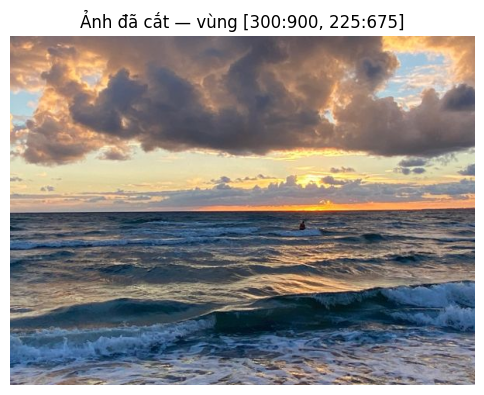

Kích thước ảnh sau khi cắt: (450, 600, 3)


In [9]:
h_img, w_img = img_rgb.shape[:2]

x1, y1 = w_img // 4, h_img // 4
x2, y2 = 3 * w_img // 4, 3 * h_img // 4

cropped = img_rgb[y1:y2, x1:x2]

plt.figure(figsize=(6, 6))
plt.imshow(cropped)
plt.title(f"Ảnh đã cắt — vùng [{x1}:{x2}, {y1}:{y2}]")
plt.axis("off")
plt.show()

print("Kích thước ảnh sau khi cắt:", cropped.shape)


### 4.2. Thay đổi kích thước hình ảnh theo tỷ lệ hoặc kích thước cố định

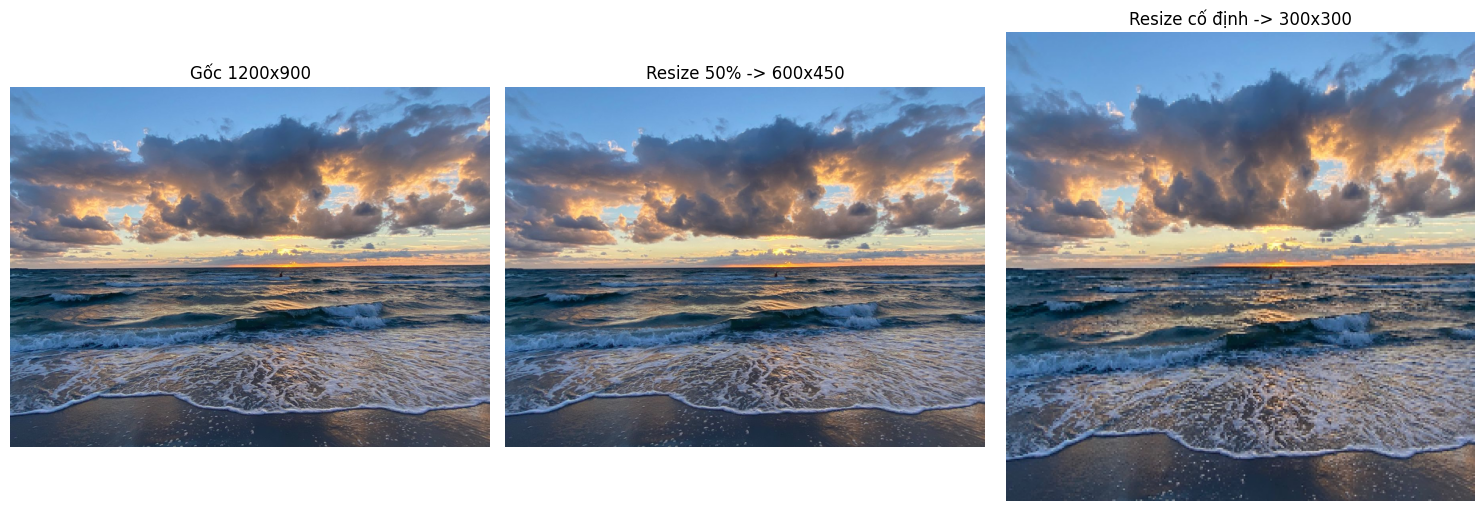

In [10]:
# Cách 1: resize theo TỈ LỆ (ví dụ: thu nhỏ còn 50%)
scale_percent = 50
new_w = int(img_rgb.shape[1] * scale_percent / 100)
new_h = int(img_rgb.shape[0] * scale_percent / 100)
resized_by_scale = cv2.resize(img_rgb, (new_w, new_h), interpolation=cv2.INTER_AREA)

# Cách 2: resize theo KÍCH THƯỚC CỐ ĐỊNH (ví dụ: 300x300, có thể méo ảnh nếu tỉ lệ khác gốc)
fixed_size = (300, 300)
resized_fixed = cv2.resize(img_rgb, fixed_size, interpolation=cv2.INTER_LINEAR)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb)
axes[0].set_title(f"Gốc {img_rgb.shape[1]}x{img_rgb.shape[0]}")
axes[1].imshow(resized_by_scale)
axes[1].set_title(f"Resize {scale_percent}% -> {new_w}x{new_h}")
axes[2].imshow(resized_fixed)
axes[2].set_title(f"Resize cố định -> {fixed_size[0]}x{fixed_size[1]}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


---
## 5. Vẽ hình cơ bản

### 5.1. Vẽ các hình cơ bản như đường thẳng, hình tròn, hình chữ nhật lên hình ảnh



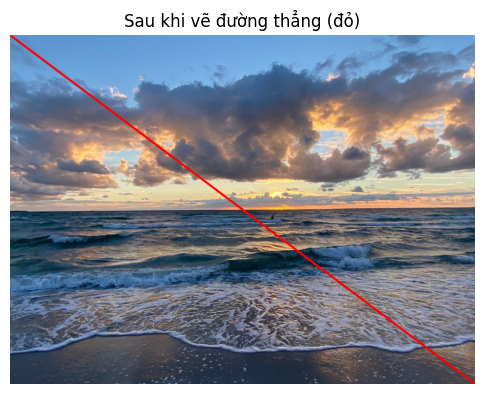

In [11]:
canvas = img_rgb.copy()
h_c, w_c = canvas.shape[:2]

# Vẽ đường thẳng: từ góc trên-trái đến góc dưới-phải, màu đỏ, độ dày 3px
cv2.line(canvas, (0, 0), (w_c, h_c), color=(255, 0, 0), thickness=3)

plt.figure(figsize=(6, 6))
plt.imshow(canvas)
plt.title("Sau khi vẽ đường thẳng (đỏ)")
plt.axis("off")
plt.show()

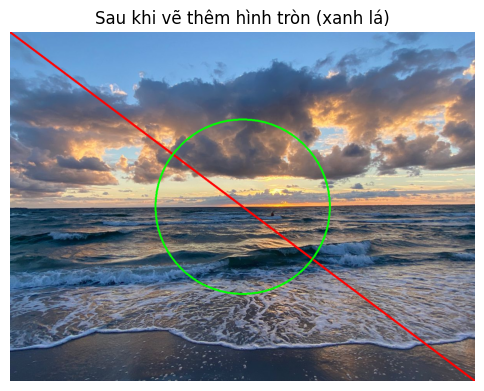

In [12]:
center = (w_c // 2, h_c // 2)
radius = min(w_c, h_c) // 4
cv2.circle(canvas, center, radius, color=(0, 255, 0), thickness=3)

plt.figure(figsize=(6, 6))
plt.imshow(canvas)
plt.title("Sau khi vẽ thêm hình tròn (xanh lá)")
plt.axis("off")
plt.show()

(np.float64(-0.5), np.float64(1199.5), np.float64(899.5), np.float64(-0.5))

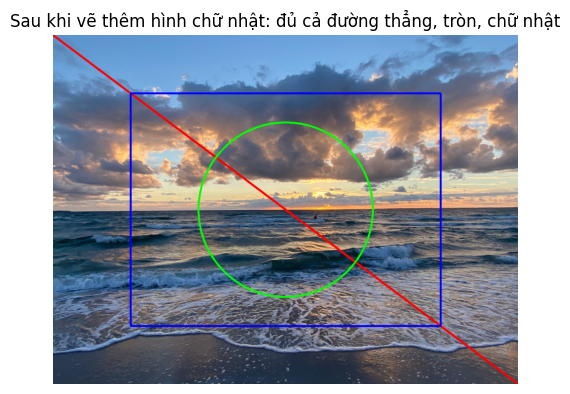

In [13]:
pt1 = (w_c // 6, h_c // 6)
pt2 = (5 * w_c // 6, 5 * h_c // 6)
cv2.rectangle(canvas, pt1, pt2, color=(0, 0, 255), thickness=3)

plt.figure(figsize=(6, 6))
plt.imshow(canvas)
plt.title("Sau khi vẽ thêm hình chữ nhật: đủ cả đường thẳng, tròn, chữ nhật")
plt.axis("off")

### 5.2. Thêm văn bản vào hình ảnh

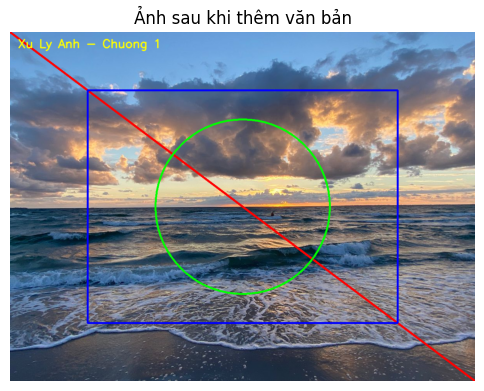

Đã lưu ảnh kết quả tại: ../data/input/outputs\anh_ve_hinh_va_chu.png


In [14]:
canvas_text = canvas.copy()

text = "Xu Ly Anh - Chuong 1"
org = (20, 40)  # tọa độ góc dưới-trái của dòng chữ
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 1
color = (255, 255, 0)  # vàng
thickness = 2

cv2.putText(canvas_text, text, org, font, font_scale, color, thickness, cv2.LINE_AA)

plt.figure(figsize=(6, 6))
plt.imshow(canvas_text)
plt.title("Ảnh sau khi thêm văn bản")
plt.axis("off")
plt.show()

# Lưu kết quả cuối cùng
final_output_path = os.path.join(OUTPUT_DIR, "anh_ve_hinh_va_chu.png")
cv2.imwrite(final_output_path, cv2.cvtColor(canvas_text, cv2.COLOR_RGB2BGR))
print("Đã lưu ảnh kết quả tại:", final_output_path)



---
##  Tổng kết

Qua notebook này, bạn đã thực hành đầy đủ 5 kỹ năng nền tảng của xử lý ảnh số:

| # | Kỹ năng | Hàm OpenCV chính |
|---|---|---|
| 1 | Cài đặt & kiểm tra môi trường | `cv2.__version__` |
| 2 | Đọc / Hiển thị / Lưu ảnh | `cv2.imread()`, `cv2.imwrite()` |
| 3 | Chuyển không gian màu | `cv2.cvtColor()` |
| 4 | Cắt xén & Resize | NumPy slicing, `cv2.resize()` |
| 5 | Vẽ hình & chữ | `cv2.line()`, `cv2.circle()`, `cv2.rectangle()`, `cv2.putText()` |

Đây chính là nền tảng để bước sang **Chương 2: Canny Edge Detector**, nơi các thao tác này (đặc biệt là chuyển grayscale và làm mờ Gaussian) sẽ được dùng làm bước tiền xử lý trước khi phát hiện cạnh.
